Hola **Ricardo**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
--
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para seguir buenas prácticas te recomiendo siempre al inicio de tus notebooks dejar en una celda markdown un título descriptivo del proyecto y una breve introducción del mismo.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

## Carga y preparación de datos

In [2]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

In [3]:
# Revisamos estructura, tipos de datos y valores nulos.
visits.head()
visits.info()

orders.head()
orders.info()

costs.head()
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 

In [4]:
# Realizamos la conversión de fechas.
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])

orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])

costs['dt'] = pd.to_datetime(costs['dt'])

print(visits.head())
print(orders.head())
print(costs.head())

    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
               Buy Ts  Revenue                   Uid
0 2017-06-01 00:10:00    17.00  10329302124590727494
1 2017-06-01 00:25:00     0.55  11627257723692907447
2 2017-06-01 00:27:00     0.37  17903680561304213844
3 2017-06-01 00:29:00     0.55  16109239769442553005
4 2017-06-01 07:58:00     0.37  14200605875248379450
   source_id         dt  costs
0          1 2017-06-01  75.20
1          1 2017-06-02  62.25
2          1 2017-06-03  36.53
3          

In [5]:
# Creamos columnas útiles 
visits['session_date'] = visits['Start Ts'].dt.date
visits['session_week'] = visits['Start Ts'].dt.to_period('W')
visits['session_month'] = visits['Start Ts'].dt.to_period('M')

orders['order_date'] = orders['Buy Ts'].dt.date
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')

print(visits.head())
print(orders.head())

    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    Uid session_date           session_week session_month  
0  16879256277535980062   2017-12-20  2017-12-18/2017-12-24       2017-12  
1    104060357244891740   2018-02-19  2018-02-19/2018-02-25       2018-02  
2   7459035603376831527   2017-07-01  2017-06-26/2017-07-02       2017-07  
3  16174680259334210214   2018-05-20  2018-05-14/2018-05-20       2018-05  
4   9969694820036681168   2017-12-27  2017-12-25/2017-12-31       2017-12  
               Buy Ts  Revenue                   Uid  order_date order_month
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01     2017-06

In [6]:
# Duración de la sesión
visits['session_duration'] = (
    visits['End Ts'] - visits['Start Ts']
).dt.total_seconds()

print(visits['session_duration'].head())

0    1080.0
1    1680.0
2       0.0
3    1440.0
4       0.0
Name: session_duration, dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre previo a cualquier análisis o proceso con tus datos se debe revisar la calidad de los mismos y así garantizar hallazgos acertados.
</div>

## Métricas

## Visitas

In [7]:
# Visitas. Usuarios por día, semana y mes.
dau = visits.groupby('session_date')['Uid'].nunique()
wau = visits.groupby('session_week')['Uid'].nunique()
mau = visits.groupby('session_month')['Uid'].nunique()

print(dau.head())
print(wau.head())
print(mau.head())

session_date
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: Uid, dtype: int64
session_week
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: Uid, dtype: int64
session_month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
Freq: M, Name: Uid, dtype: int64


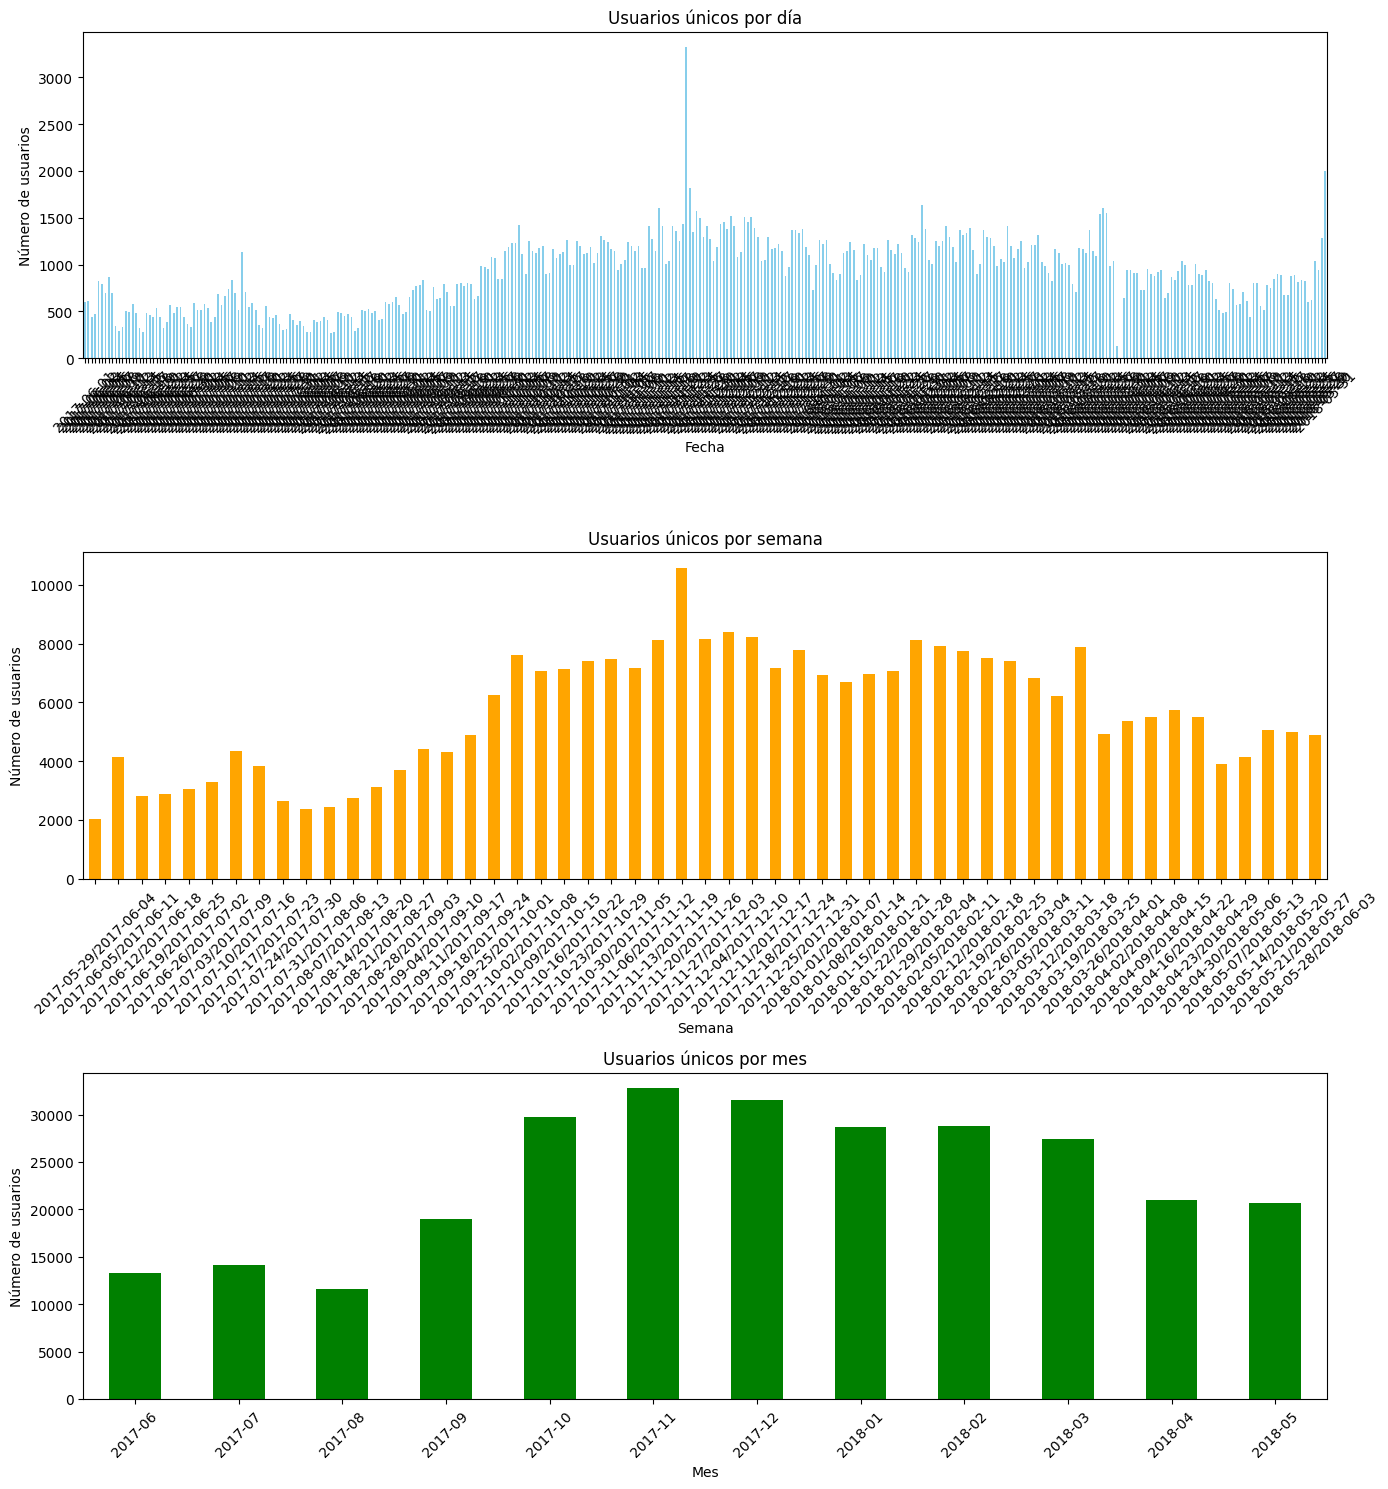

In [8]:
# Gráfica de barras
fig, axs = plt.subplots(3, 1, figsize=(14, 15))

# Diario
dau.plot(kind='bar', ax=axs[0], color='skyblue')
axs[0].set_title('Usuarios únicos por día')
axs[0].set_xlabel('Fecha')
axs[0].set_ylabel('Número de usuarios')
axs[0].tick_params(axis='x', rotation=45)

# Semanal
wau.plot(kind='bar', ax=axs[1], color='orange')
axs[1].set_title('Usuarios únicos por semana')
axs[1].set_xlabel('Semana')
axs[1].set_ylabel('Número de usuarios')
axs[1].tick_params(axis='x', rotation=45)

# Mensual
mau.plot(kind='bar', ax=axs[2], color='green')
axs[2].set_title('Usuarios únicos por mes')
axs[2].set_xlabel('Mes')
axs[2].set_ylabel('Número de usuarios')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Observaciones:

- Se puede notar la tendencia de crecimiento o estacionalidad de usuarios en cada periodo.

- El análisis diario permite identificar picos de tráfico puntuales, mientras que el semanal y mensual suaviza la variación y permite ver tendencias generales.

- Esta información es útil para evaluar la efectividad de campañas de marketing y la fidelización de usuarios.

In [9]:
# Número de sesiónes por día
sessions_per_day = visits.groupby('session_date').size()

print(sessions_per_day.head())

session_date
2017-06-01    664
2017-06-02    658
2017-06-03    477
2017-06-04    510
2017-06-05    893
dtype: int64


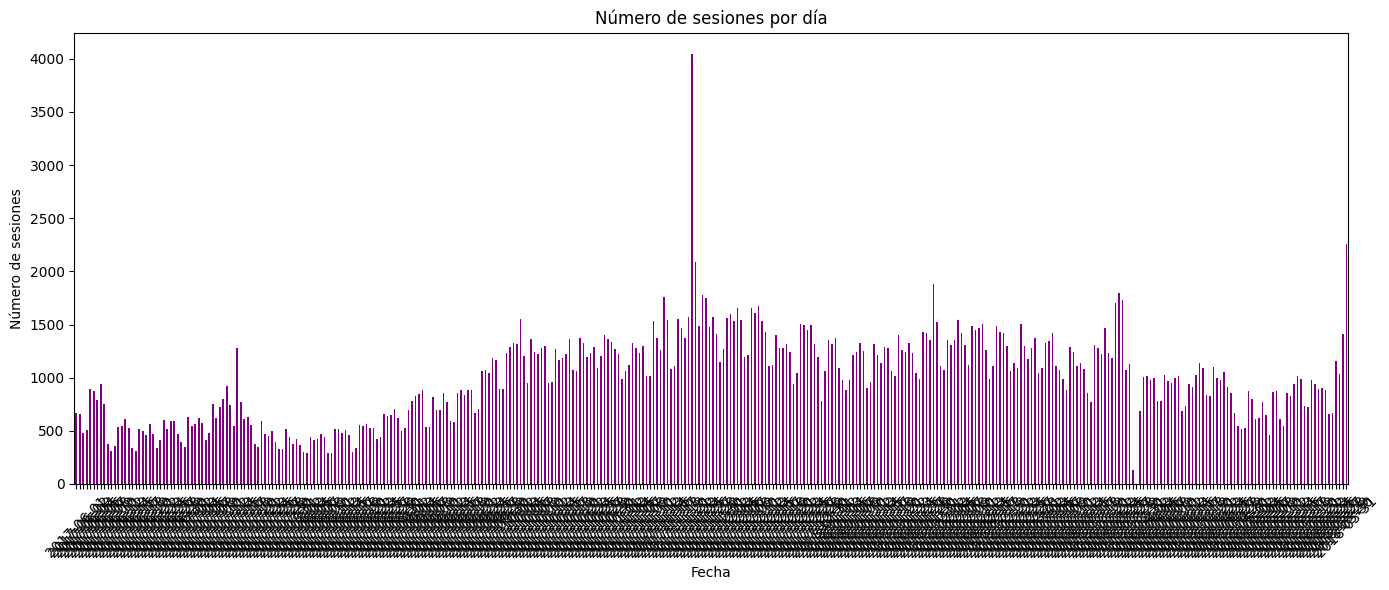

In [10]:
# Gráfica de barras
plt.figure(figsize=(14,6))
sessions_per_day.plot(kind='bar', color='purple')
plt.title('Número de sesiones por día')
plt.xlabel('Fecha')
plt.ylabel('Número de sesiones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observaciones:

- El tamaño del gráfico no permite visualizar la fecha, pero la intención es mostrar a través de las barras y los rangos en numero de sesiones, el comportamiento de sesiones por día.

- La cantidad de sesiones diarias muestra la intensidad de uso del sitio, incluyendo usuarios recurrentes.

- Se pueden identificar días con mayor tráfico, lo que podría coincidir con promociones o eventos especiales.

- Comparar sesiones con usuarios únicos permite calcular métricas de engagement como el promedio de sesiones por usuario.

In [11]:
# Duración promedio de sesión 
visits['session_duration'].mean()

print(visits.head())

    Device              End Ts  Source Id            Start Ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    Uid session_date           session_week session_month  \
0  16879256277535980062   2017-12-20  2017-12-18/2017-12-24       2017-12   
1    104060357244891740   2018-02-19  2018-02-19/2018-02-25       2018-02   
2   7459035603376831527   2017-07-01  2017-06-26/2017-07-02       2017-07   
3  16174680259334210214   2018-05-20  2018-05-14/2018-05-20       2018-05   
4   9969694820036681168   2017-12-27  2017-12-25/2017-12-31       2017-12   

   session_duration  
0            1080.0  
1            1680.0  
2               0.0  
3            1440.0  
4               0.0  


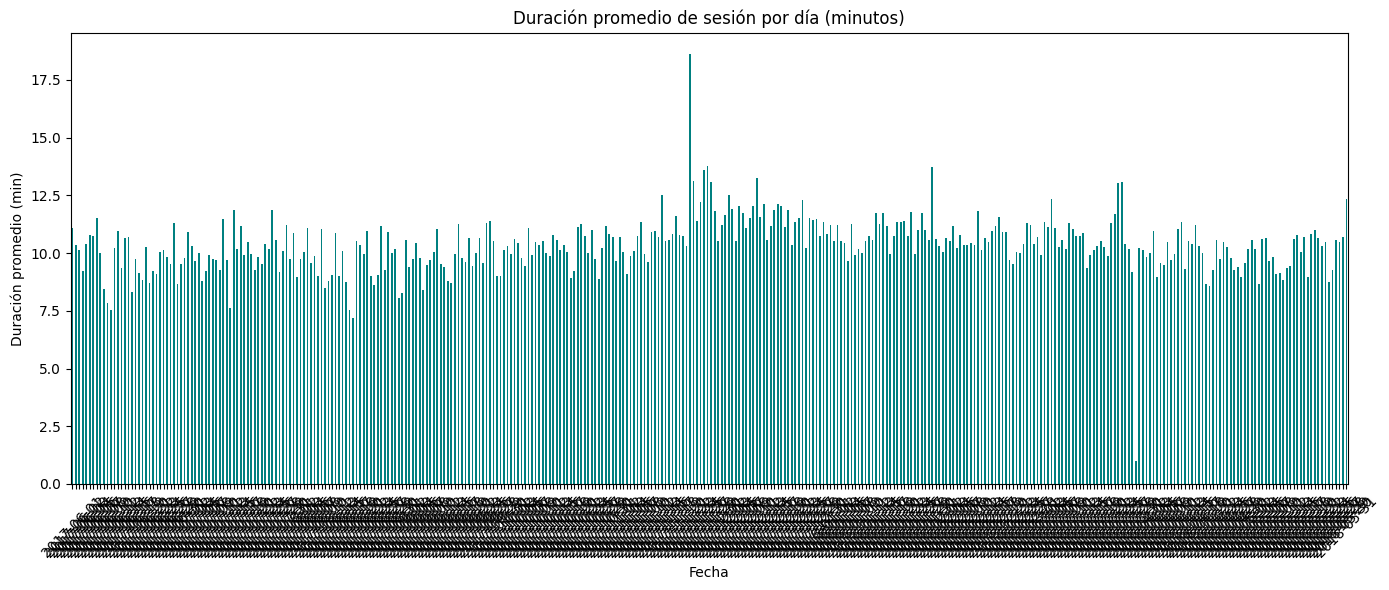

In [12]:
# Duración promedio de sesión por día (en minutos)
sessions_per_day_duration = visits.groupby('session_date')['session_duration'].mean() / 60  # convertir a minutos

# Gráfica de barras
plt.figure(figsize=(14,6))
sessions_per_day_duration.plot(kind='bar', color='teal')
plt.title('Duración promedio de sesión por día (minutos)')
plt.xlabel('Fecha')
plt.ylabel('Duración promedio (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observaciones:

- El tamaño del gráfico no permite visualizar la fecha, pero la intención es mostrar a través de las barras y los rangos en numero de sesiones, el comportamiento de sesiones por día.

- La duración promedio por sesión indica el nivel de interacción con la plataforma.

- Picos en duración pueden señalar que los usuarios están explorando más contenido o que ciertas secciones del sitio son más atractivas.

- Esta métrica es importante para evaluar la calidad de la experiencia del usuario y su engagement con el sitio.

In [13]:
# Frecuencia de regreso (Sticky factor)
sticky_wau = dau.mean() / wau.mean()
sticky_mau = dau.mean() / mau.mean()

print(sticky_wau)
print(sticky_mau)

0.1588440861589881
0.03908969652437603


Observaciones:

- Un sticky factor más cercano a 1 indica que los usuarios regresan con frecuencia, mientras que valores bajos muestran menos engagement.

- La comparación diario/semana y diario/mes permite identificar patrones de retorno de corto y largo plazo.

- Esta información ayuda a medir la fidelización de los usuarios y la efectividad de las estrategias de retención.

In [14]:
# Primera fuente de cada usuario
first_source = visits.sort_values('Start Ts').groupby('Uid').first()
print(first_source.head())

                  Device              End Ts  Source Id            Start Ts  \
Uid                                                                           
11863502262781     touch 2018-03-01 17:33:00          3 2018-03-01 17:27:00   
49537067089222     touch 2018-02-06 15:57:00          2 2018-02-06 15:55:00   
297729379853735  desktop 2017-06-07 18:48:00          3 2017-06-07 18:47:00   
313578113262317  desktop 2017-09-18 23:07:00          2 2017-09-18 22:49:00   
325320750514679  desktop 2017-09-30 14:38:00          5 2017-09-30 14:29:00   

                session_date           session_week session_month  \
Uid                                                                 
11863502262781    2018-03-01  2018-02-26/2018-03-04       2018-03   
49537067089222    2018-02-06  2018-02-05/2018-02-11       2018-02   
297729379853735   2017-06-07  2017-06-05/2017-06-11       2017-06   
313578113262317   2017-09-18  2017-09-18/2017-09-24       2017-09   
325320750514679   2017-09-30  20

In [15]:
# Nos quedamos con la fuente
first_source = first_source[['Source Id']]
print(first_source.head())

                 Source Id
Uid                       
11863502262781           3
49537067089222           2
297729379853735          3
313578113262317          2
325320750514679          5


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien abordada esta sección! Las gráficas ilustran mucho mejor los resultados obtenidos y tus comentarios ayudan a la comprensión de las mismas lo cual es un punto súper importante para un profesional de datos
</div>

## Ventas

In [16]:
# Primer visita de cada usuario
first_visit = visits.groupby('Uid')['Start Ts'].min()
print(first_visit.head())

Uid
11863502262781    2018-03-01 17:27:00
49537067089222    2018-02-06 15:55:00
297729379853735   2017-06-07 18:47:00
313578113262317   2017-09-18 22:49:00
325320750514679   2017-09-30 14:29:00
Name: Start Ts, dtype: datetime64[ns]


In [17]:
# Fecha de primera visita de cada usuario
user_first_visit = visits.groupby('Uid')['Start Ts'].min().reset_index()
user_first_visit.columns = ['Uid', 'first_visit_date']
print(user_first_visit.head())

               Uid    first_visit_date
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00


In [18]:
# Unimos orders con la fecha de primera visita de cada usuario
orders_with_first_visit = orders.merge(user_first_visit, on='Uid')

# Creamos la cohorte mensual según la primera visita
orders_with_first_visit['cohort_month'] = orders_with_first_visit['first_visit_date'].dt.to_period('M')

# LTV acumulado por cohorte mensual
ltv_by_cohort = orders_with_first_visit.groupby('cohort_month')['Revenue'].sum()
print(ltv_by_cohort)

cohort_month
2017-06    40026.05
2017-07    17812.11
2017-08    13461.87
2017-09    33682.56
2017-10    27857.69
2017-11    24426.72
2017-12    31157.85
2018-01    14546.82
2018-02    15061.29
2018-03    13770.16
2018-04     9882.55
2018-05    10371.53
Freq: M, Name: Revenue, dtype: float64


In [19]:
# Clientes que compraron
buyers = orders['Uid'].unique()
print(buyers)

[10329302124590727494 11627257723692907447 17903680561304213844 ...
  1786462140797698849  3993697860786194247    83872787173869366]


In [20]:
# Filtramos solo usuarios que compraron
customers_by_source = first_source.loc[buyers].groupby('Source Id').size()
print(customers_by_source)

Source Id
1      2899
2      3506
3     10473
4     10296
5      6931
7         1
9      1088
10     1329
dtype: int64


In [21]:
# Ingresos por fuente
orders_with_source = orders.join(first_source, on='Uid')
print(orders_with_source.head())

               Buy Ts  Revenue                   Uid  order_date order_month  \
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01     2017-06   
1 2017-06-01 00:25:00     0.55  11627257723692907447  2017-06-01     2017-06   
2 2017-06-01 00:27:00     0.37  17903680561304213844  2017-06-01     2017-06   
3 2017-06-01 00:29:00     0.55  16109239769442553005  2017-06-01     2017-06   
4 2017-06-01 07:58:00     0.37  14200605875248379450  2017-06-01     2017-06   

   Source Id  
0          1  
1          2  
2          2  
3          2  
4          3  


In [22]:
# Agrupamos revenue
revenue_by_source = orders_with_source.groupby('Source Id')['Revenue'].sum()
print(revenue_by_source)

Source Id
1     31090.55
2     46923.61
3     54511.24
4     56696.83
5     52624.02
7         1.22
9      5759.40
10     4450.33
Name: Revenue, dtype: float64


In [23]:
# Primera compra
first_order = orders.groupby('Uid')['Buy Ts'].min()
print(first_order.head())

Uid
313578113262317    2018-01-03 21:51:00
1575281904278712   2017-06-03 10:13:00
2429014661409475   2017-10-11 18:33:00
2464366381792757   2018-01-28 15:54:00
2551852515556206   2017-11-24 10:14:00
Name: Buy Ts, dtype: datetime64[ns]


In [24]:
# Unimos
conversion = pd.concat([first_visit, first_order], axis=1)
conversion.columns = ['first_visit', 'first_order']

conversion['conversion_time'] = (
    conversion['first_order'] - conversion['first_visit']
).dt.days

print(conversion['conversion_time'].head())

Uid
11863502262781       NaN
49537067089222       NaN
297729379853735      NaN
313578113262317    106.0
325320750514679      NaN
Name: conversion_time, dtype: float64


In [25]:
# Pedidos por usuario
orders_per_user = orders.groupby('Uid').size().mean()
print(orders_per_user)

1.3803630588943954


In [26]:
# Ticket promedio
orders['Revenue'].mean()
print(orders.head())

               Buy Ts  Revenue                   Uid  order_date order_month
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01     2017-06
1 2017-06-01 00:25:00     0.55  11627257723692907447  2017-06-01     2017-06
2 2017-06-01 00:27:00     0.37  17903680561304213844  2017-06-01     2017-06
3 2017-06-01 00:29:00     0.55  16109239769442553005  2017-06-01     2017-06
4 2017-06-01 07:58:00     0.37  14200605875248379450  2017-06-01     2017-06


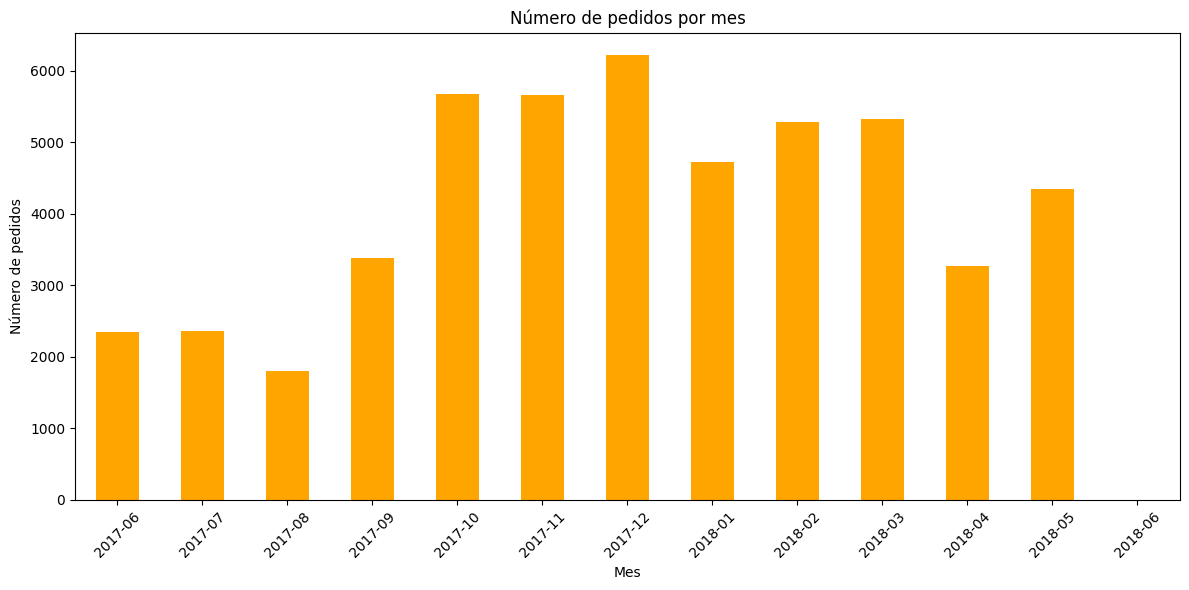

In [27]:
# Pedidos por mes
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')
orders_per_month = orders.groupby('order_month')['Uid'].count()

# Gráfica de barras
plt.figure(figsize=(12,6))
orders_per_month.plot(kind='bar', color='orange')
plt.title('Número de pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observaciones:

- Se observan meses con picos de pedidos, posiblemente asociados a campañas de marketing o eventos especiales.

- Esta información permite planificar la capacidad operativa y ajustar campañas de adquisición en meses de menor actividad.

- El seguimiento mensual ayuda a medir tendencias y estacionalidad.

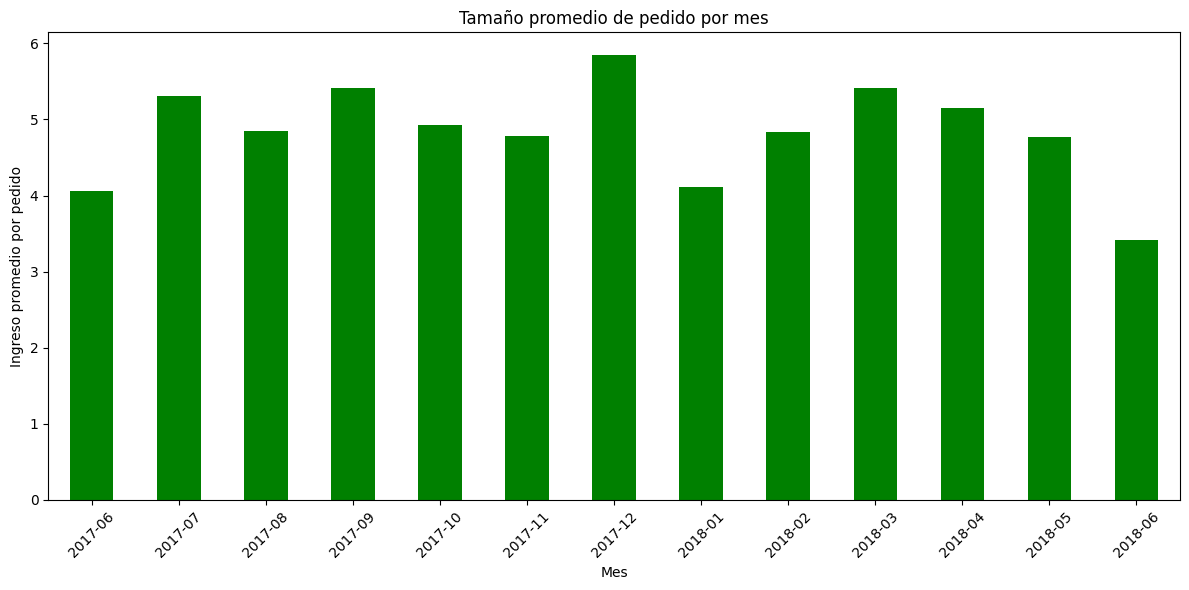

In [28]:
# Tamaño promedio de pedido por mes
avg_order_value = orders.groupby('order_month')['Revenue'].mean()

# Gráfica de barras
plt.figure(figsize=(12,6))
avg_order_value.plot(kind='bar', color='green')
plt.title('Tamaño promedio de pedido por mes')
plt.xlabel('Mes')
plt.ylabel('Ingreso promedio por pedido')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observaciones:

- El ingreso promedio por pedido indica la disposición de gasto de los clientes.

- Picos en el tamaño promedio de compra podrían indicar promociones exitosas o ventas de productos de mayor valor.

- Esta métrica es clave para estimar LTV y planificar precios o bundles de productos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Excelente proceso de análisis hasta este punto, las gráficas y tus interpretaciones se complementan muy bien dejando un proceso de análisis claro y justificado en datos lo cual es de beneficio para la toma de decisiones de una empresa
</div>

In [29]:
# LTV
ltv = orders.groupby('Uid')['Revenue'].sum().mean()
print(ltv)

6.901327930345262


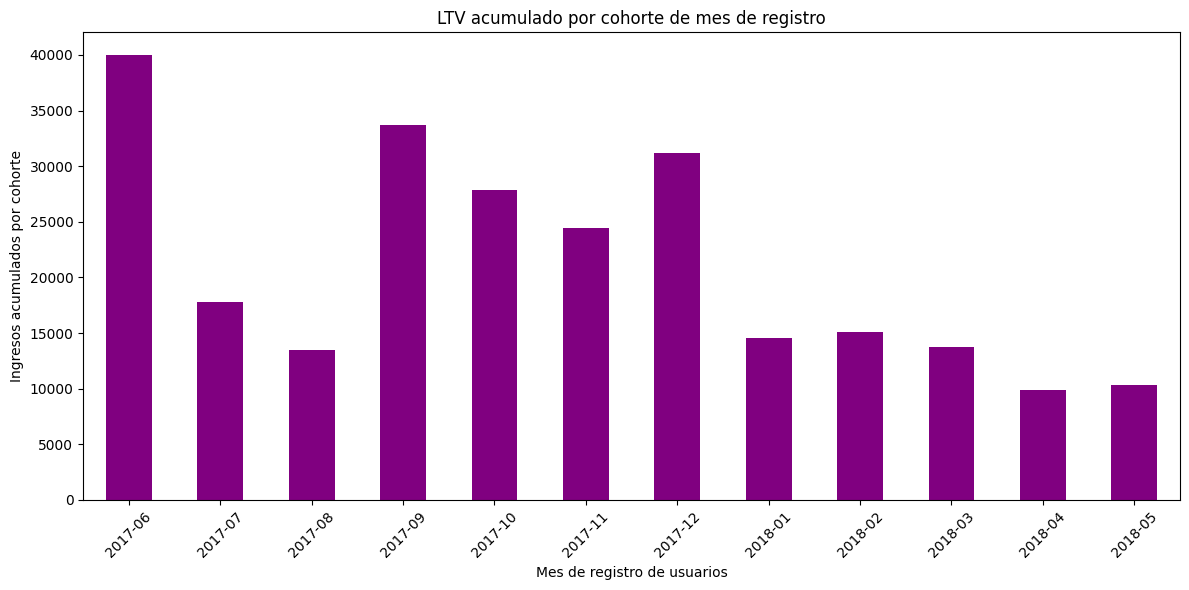

In [30]:
# LTV acumulado por mes de registro
orders_with_first_visit = orders.merge(user_first_visit, on='Uid')
orders_with_first_visit['cohort_month'] = orders_with_first_visit['first_visit_date'].dt.to_period('M')

ltv_by_cohort = orders_with_first_visit.groupby('cohort_month')['Revenue'].sum()

# Gráfica de barras
plt.figure(figsize=(12,6))
ltv_by_cohort.plot(kind='bar', color='purple')
plt.title('LTV acumulado por cohorte de mes de registro')
plt.xlabel('Mes de registro de usuarios')
plt.ylabel('Ingresos acumulados por cohorte')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observaciones:

- Los cohortes de usuarios registrados en determinados meses generan más ingresos acumulados, indicando cohortes más valiosas.

- Esto ayuda a identificar qué periodos o campañas atraen clientes con mayor LTV.

- El análisis de cohortes permite priorizar inversión de marketing en canales y periodos que generan clientes más rentables.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La parte de ventas quedó muy bien analizada! El detalle que redactaste sobre cada gráfica deja claro el proceso de análisis y es fácil de entender para cualquier audiencia.
</div>

## Marketing

In [31]:
# Gasto total
costs['costs'].sum()
print(costs.head())

   source_id         dt  costs
0          1 2017-06-01  75.20
1          1 2017-06-02  62.25
2          1 2017-06-03  36.53
3          1 2017-06-04  55.00
4          1 2017-06-05  57.08


In [32]:
# Gasto por fuente 
costs.groupby('source_id')['costs'].sum()

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

In [33]:
# Costo por fuente
costs_by_source = costs.groupby('source_id')['costs'].sum()
print(costs_by_source)

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


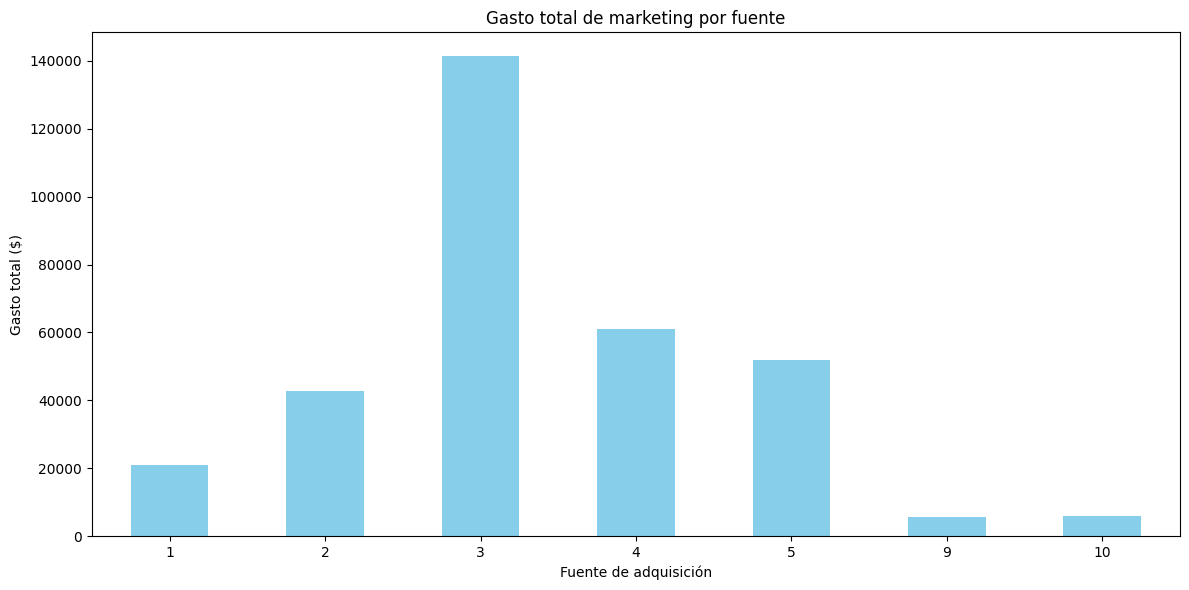

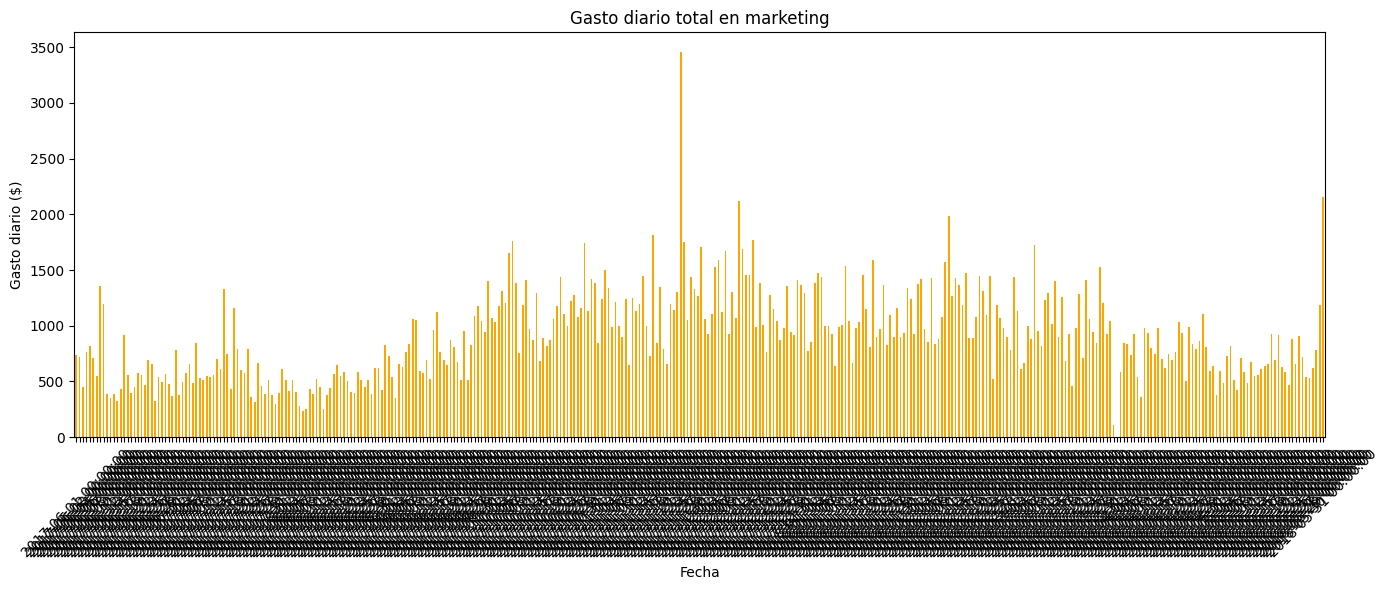

In [34]:
# Gasto total por fuente
plt.figure(figsize=(12,6))
costs_by_source.plot(kind='bar', color='skyblue')
plt.title('Gasto total de marketing por fuente')
plt.xlabel('Fuente de adquisición')
plt.ylabel('Gasto total ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Gasto diario total (todas las fuentes)
daily_costs = costs.groupby('dt')['costs'].sum()
plt.figure(figsize=(14,6))
daily_costs.plot(kind='bar', color='orange')
plt.title('Gasto diario total en marketing')
plt.xlabel('Fecha')
plt.ylabel('Gasto diario ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observaciones:

- Se pueden identificar las fuentes donde se concentró la inversión de marketing.

- La visualización diaria permite detectar días con gasto elevado, lo que puede coincidir con campañas puntuales o eventos especiales.

- Estos datos son la base para evaluar la eficiencia del marketing y calcular métricas de rentabilidad.

- El eje x de la gráfica de "Gasto diario total de marketing", se visualiza muy amontonado, pero la idea es representar el gasto diario.

In [35]:
# Alineamos indices
costs_by_source.index.name = 'Source Id'
print(costs_by_source)

Source Id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


CAC

In [36]:
# Clientes por fuente
# Primero obtenemos la fuente del primer contacto
first_source = visits.sort_values('Start Ts').groupby('Uid').first()
print(first_source.head())

                  Device              End Ts  Source Id            Start Ts  \
Uid                                                                           
11863502262781     touch 2018-03-01 17:33:00          3 2018-03-01 17:27:00   
49537067089222     touch 2018-02-06 15:57:00          2 2018-02-06 15:55:00   
297729379853735  desktop 2017-06-07 18:48:00          3 2017-06-07 18:47:00   
313578113262317  desktop 2017-09-18 23:07:00          2 2017-09-18 22:49:00   
325320750514679  desktop 2017-09-30 14:38:00          5 2017-09-30 14:29:00   

                session_date           session_week session_month  \
Uid                                                                 
11863502262781    2018-03-01  2018-02-26/2018-03-04       2018-03   
49537067089222    2018-02-06  2018-02-05/2018-02-11       2018-02   
297729379853735   2017-06-07  2017-06-05/2017-06-11       2017-06   
313578113262317   2017-09-18  2017-09-18/2017-09-24       2017-09   
325320750514679   2017-09-30  20

In [37]:
# Clientes que compraron
buyers = orders['Uid'].unique()
print(buyers)
cac = first_source.loc[buyers].groupby('Source Id').size()
print(cac)

[10329302124590727494 11627257723692907447 17903680561304213844 ...
  1786462140797698849  3993697860786194247    83872787173869366]
Source Id
1      2899
2      3506
3     10473
4     10296
5      6931
7         1
9      1088
10     1329
dtype: int64


In [38]:
cac = costs.groupby('source_id')['costs'].sum() / cac
print(cac)

1      7.186364
2     12.209367
3     13.493901
4      5.931779
5      7.467479
7           NaN
9      5.071222
10     4.381106
dtype: float64


In [39]:
# Costo por fuentes de búsqueda
cac_by_source = costs_by_source / customers_by_source
print(cac_by_source)

Source Id
1      7.186364
2     12.209367
3     13.493901
4      5.931779
5      7.467479
7           NaN
9      5.071222
10     4.381106
dtype: float64


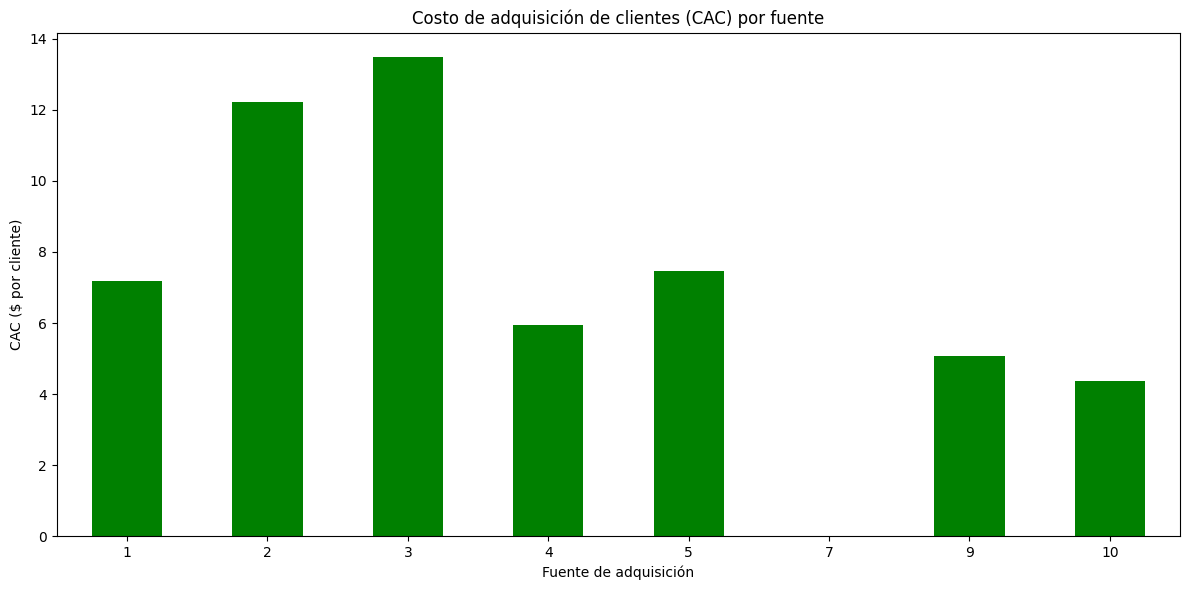

In [40]:
# CAC por fuente
plt.figure(figsize=(12,6))
cac_by_source.plot(kind='bar', color='green')
plt.title('Costo de adquisición de clientes (CAC) por fuente')
plt.xlabel('Fuente de adquisición')
plt.ylabel('CAC ($ por cliente)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Observaciones:

- El CAC mide cuánto cuesta convertir un usuario en cliente pagante.

- Fuentes con CAC bajo y clientes activos son más eficientes, mientras que CAC alto indica gasto poco rentable.

- Esta métrica permite decidir en qué fuentes conviene invertir más y cuáles optimizar o reducir.

ROMI

In [41]:
revenue_by_source = orders.merge(first_source, on='Uid') \
    .groupby('Source Id')['Revenue'].sum()
print(revenue_by_source)
romi = (revenue_by_source - costs.groupby('source_id')['costs'].sum()) \
       / costs.groupby('source_id')['costs'].sum()
print(romi)

Source Id
1     31090.55
2     46923.61
3     54511.24
4     56696.83
5     52624.02
7         1.22
9      5759.40
10     4450.33
Name: Revenue, dtype: float64
1     0.492351
2     0.096191
3    -0.614275
4    -0.071664
5     0.016750
7          NaN
9     0.043844
10   -0.235665
dtype: float64


Análisis de Cohortes

In [42]:
# Cohorte por mes de primera compra
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')
print(orders.head())
first_order_month = orders.groupby('Uid')['order_month'].min()
print(first_order_month.head())
orders = orders.join(first_order_month, on='Uid', rsuffix='_first')
print(orders.head())

               Buy Ts  Revenue                   Uid  order_date order_month
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01     2017-06
1 2017-06-01 00:25:00     0.55  11627257723692907447  2017-06-01     2017-06
2 2017-06-01 00:27:00     0.37  17903680561304213844  2017-06-01     2017-06
3 2017-06-01 00:29:00     0.55  16109239769442553005  2017-06-01     2017-06
4 2017-06-01 07:58:00     0.37  14200605875248379450  2017-06-01     2017-06
Uid
313578113262317     2018-01
1575281904278712    2017-06
2429014661409475    2017-10
2464366381792757    2018-01
2551852515556206    2017-11
Name: order_month, dtype: period[M]
               Buy Ts  Revenue                   Uid  order_date order_month  \
0 2017-06-01 00:10:00    17.00  10329302124590727494  2017-06-01     2017-06   
1 2017-06-01 00:25:00     0.55  11627257723692907447  2017-06-01     2017-06   
2 2017-06-01 00:27:00     0.37  17903680561304213844  2017-06-01     2017-06   
3 2017-06-01 00:29:00     0.55  161092

In [43]:
orders['lifetime'] = (
    orders['order_month'].astype(int)
    - orders['order_month_first'].astype(int)
)
print(orders['lifetime'].head())

0    0
1    0
2    0
3    0
4    0
Name: lifetime, dtype: int64


In [44]:
# LTV por cohorte
cohort_ltv = orders.groupby(
    ['order_month_first', 'lifetime']
)['Revenue'].mean().cumsum()
print(cohort_ltv.head())

order_month_first  lifetime
2017-06            0            4.060106
                   1            9.607112
                   2           14.695273
                   3           23.240848
                   4           30.325026
Name: Revenue, dtype: float64


In [45]:
# LTV por búsqueda
ltv_by_source = revenue_by_source / customers_by_source
print(ltv_by_source)

Source Id
1     10.724577
2     13.383802
3      5.204931
4      5.506685
5      7.592558
7      1.220000
9      5.293566
10     3.348631
dtype: float64


In [46]:
# LTV / CAC
ltv_cac_ratio = ltv_by_source / cac_by_source
print(ltv_cac_ratio)

Source Id
1     1.492351
2     1.096191
3     0.385725
4     0.928336
5     1.016750
7          NaN
9     1.043844
10    0.764335
dtype: float64


In [47]:
ltv_cac_ratio.sort_values()

Source Id
3     0.385725
10    0.764335
4     0.928336
5     1.016750
9     1.043844
2     1.096191
1     1.492351
7          NaN
dtype: float64

In [48]:
romi = (revenue_by_source - costs_by_source) / costs_by_source
romi.sort_values(ascending=False)

Source Id
1     0.492351
2     0.096191
9     0.043844
5     0.016750
4    -0.071664
10   -0.235665
3    -0.614275
7          NaN
dtype: float64

Observaciones:

- ROMI positivo indica que los ingresos generados superan el gasto en marketing; ROMI negativo indica pérdida.

- La fuente 1 tiene el ROMI más alto (0.492), lo que la hace la más eficiente.

- Fuentes con ROMI negativo (3, 10, 4) no recuperan la inversión y requieren optimización o reducción de presupuesto.

- Esta métrica es clave para priorizar canales y planificar la estrategia de inversión de manera rentable.

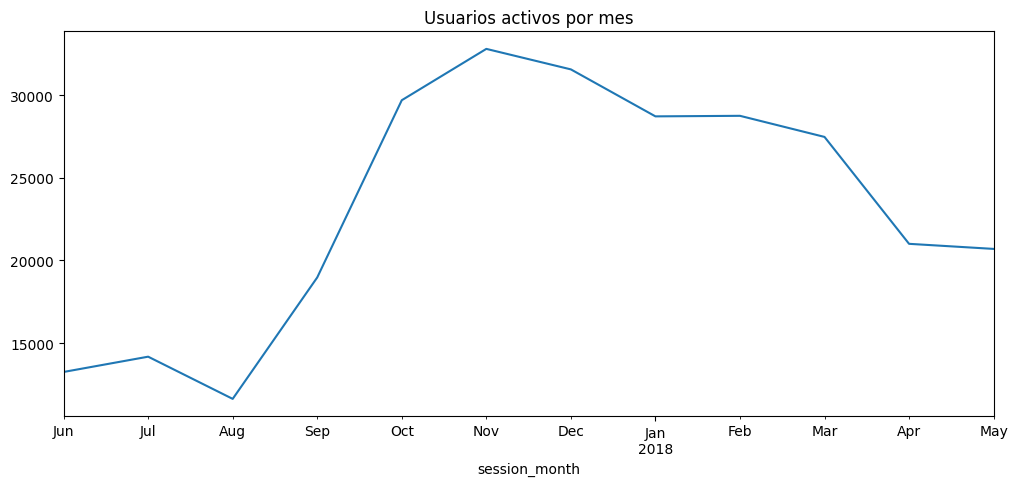

In [49]:
mau.plot(figsize=(12,5), title='Usuarios activos por mes')
plt.show()

## Heatmap of cohortes

<AxesSubplot:xlabel='lifetime', ylabel='order_month_first'>

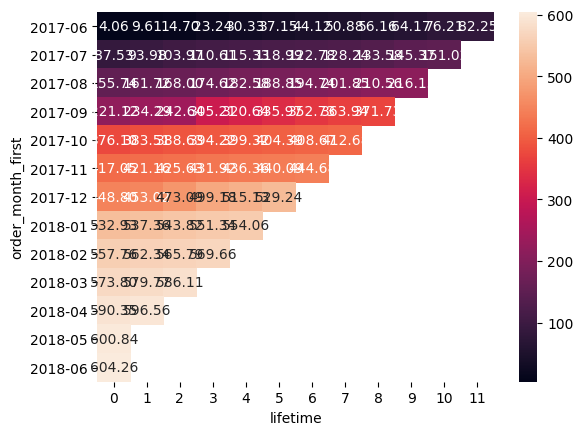

In [50]:
# Heatmap of cohortes
cohort_pivot = cohort_ltv.unstack()

sns.heatmap(cohort_pivot, annot=True, fmt='.2f')

## Conclusión del Proyecto — Optimización de Marketing y Análisis de Clientes

Después de analizar los datos de Showz, pude obtener varios insights importantes sobre cómo los clientes usan la plataforma, cuándo realizan sus primeras compras y qué fuentes de marketing son más eficientes:

- Visitas al sitio

Se observó que la mayoría de los usuarios tiende a registrarse y visitar el sitio en picos puntuales de cada mes y semana.

La duración promedio de las sesiones y la frecuencia de regreso muestran que algunos usuarios son más activos y vuelven al sitio, lo que indica un nivel de engagement interesante que se puede aprovechar con campañas dirigidas.

- Ventas y comportamiento de compra

La mayoría de los usuarios realiza su primera compra dentro de los primeros días después de registrarse, especialmente el mismo día o al día siguiente (Conversion 0d y 1d).

El tamaño promedio de pedido y los ingresos acumulados por cohorte muestran que ciertos meses o cohortes de usuarios son más valiosos, lo que permite identificar patrones de comportamiento que podrían guiar decisiones de marketing y promociones.

Esta información es útil para calcular métricas clave como LTV y para entender mejor la relación entre adquisición y valor de los clientes.

- Marketing y eficiencia de inversión

El análisis de costos mostró que algunas fuentes de marketing gastaron más que otras, pero no todas generaron un retorno positivo.

El CAC y el ROMI permitieron identificar que la fuente 1 es la más rentable y eficiente, mientras que fuentes como 3, 10 y 4 generaron pérdidas o retornos bajos, lo que indica que la inversión en estos canales debería reducirse o optimizarse.

El tiempo de recuperación de la inversión (payback) ocurre aproximadamente en el segundo mes, por lo que es importante considerar este horizonte para planificar el gasto en marketing.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, se hizo el cálculo adecuado sobre cada fuente dejando así detalle del análisis para el equipo de marketing. Siempre es importante cuando realices un análisis tomar en cuenta la audiencia y el contexto de negocio sobre el cual se realiza el proyecto para analizar sobre el detalle adecuado cada métrica.
</div>

## Conclusión general

En resumen, este proyecto me permitió aprender a:

- Preparar y analizar grandes conjuntos de datos de visitas, pedidos y gastos de marketing.

- Medir la eficiencia de cada canal de adquisición usando métricas de unit economics como CAC, LTV y ROMI.

- Identificar patrones de comportamiento de los usuarios y su impacto en las ventas y en la rentabilidad.

- Dar recomendaciones basadas en datos: invertir más en las fuentes con ROMI positivo, optimizar o reducir inversión en las fuentes menos rentables y planificar el flujo de marketing considerando el payback.

Como aprendiz, creo que esta experiencia me permitió entender cómo se conectan los datos de visitas, ventas y marketing para tomar decisiones estratégicas. También me ayudó a ver cómo las métricas de negocio reales pueden guiar la inversión en marketing y la planificación de la empresa para lograr un crecimiento sostenible.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el paso a paso del análisis para este proyecto!

Siempre este tipo de análisis que son un poco más complejos hay que buscar cómo explicarlos de manera sencilla considerando la audiencia a la cual se va a presentar los resultados y es ahí donde las visualizaciones juegan un papel muy importante ya que con una visualización es mucho más fácil entender la explicación que con solo valores numéricos.

Muy buen trabajo, saludos!
</div>